In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/EASA13.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/EASA13.csv


,"In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?",Analyse
0,"When the button is pressed, even though the a...",Evaluate
1,A differential relay in a twin generator syste...,Analyse
2,A DME is in auto stand by when,Understand
3,A GPS aerial is polarised,Remember
4,A gyroscope with a vertical spin axis has the ...,Understand


In [ ]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Ensure text is a string before processing
    if not isinstance(text, str):
        return [] # Or handle as appropriate, e.g., str(text) or skip

    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Rename the first column to 'Question' if it's not already named 'Question'
# This assumes the first column is the intended 'Question' column
if df.columns[0] != 'Question':
    original_column_name = df.columns[0]
    df.rename(columns={original_column_name: 'Question'}, inplace=True)
    print(f"Renamed column '{original_column_name}' to 'Question'.")

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Renamed column ' In an autopilot system, if the aircraft constantly deviates to the left, what is the likely failed component in the inner loop?' to 'Question'.
Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ..."
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,..."
2,A DME is in auto stand by when,"[dme, auto, stand]"
3,A GPS aerial is polarised,"[gps, aerial, polarised]"
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque..."


In [ ]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,"When the button is pressed, even though the a...","[button, pressed, even, though, autothrottle, ...",button pressed even though autothrottle engage...
1,A differential relay in a twin generator syste...,"[differential, relay, twin, generator, system,...",differential relay twin generator system cause
2,A DME is in auto stand by when,"[dme, auto, stand]",dme auto stand
3,A GPS aerial is polarised,"[gps, aerial, polarised]",gps aerial polarised
4,A gyroscope with a vertical spin axis has the ...,"[gyroscope, vertical, spin, axis, roll, torque...",gyroscope vertical spin axis roll torque motor...


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Analyse' column to create 'labels'
df['labels'] = label_encoder.fit_transform(df['Analyse'])

print("Encoded 'Analyse' column into numerical labels.")
display(df[['Analyse', 'labels']].head())

Encoded 'Analyse' column into numerical labels.


,Analyse,labels
0,Evaluate,4
1,Analyse,0
2,Understand,6
3,Remember,5
4,Understand,6


In [ ]:
from sklearn.model_selection import train_test_split

# Identify labels with only one instance
label_counts = df['labels'].value_counts()
single_instance_labels = label_counts[label_counts == 1].index

# Filter out rows corresponding to single-instance labels
df_filtered = df[~df['labels'].isin(single_instance_labels)].copy()

# Split the data into training and testing sets using the filtered DataFrame
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['Processed_Questions_Str'],
    df_filtered['labels'],
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=df_filtered['labels'] # Ensure class distribution is maintained on the filtered data
)

print("Dataset split into training and testing sets:")
print(f"Original df shape: {df.shape}")
print(f"Filtered df_filtered shape: {df_filtered.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
Original df shape: (698, 5)
Filtered df_filtered shape: (697, 5)
X_train shape: (557,)
X_test shape: (140,)
y_train shape: (557,)
y_test shape: (140,)


**Reasoning**:
Although the training loop was previously executed, a warning related to data handling in the custom dataset was identified and fixed. The data loaders have now been recreated with the necessary correction. To ensure the BERT model is fine-tuned with the properly prepared data, I will re-execute the training loop with the updated `train_loader`.

In [ ]:
model.train() # Set the model to training mode

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    total_loss = 0
    for batch in train_loader:
        # Move batch to the device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Average training loss for Epoch {epoch + 1}: {avg_train_loss:.4f}")

print("Training complete.")


Epoch 1/3
Average training loss for Epoch 1: 0.4086

Epoch 2/3
Average training loss for Epoch 2: 0.3120

Epoch 3/3
Average training loss for Epoch 3: 0.2545
Training complete.


# Task
Fine-tune a BERT model for text classification using the `X_train` and `y_train` data, evaluate its performance on `X_test` and `y_test` by calculating accuracy, precision, recall, and F1-score, generate a confusion matrix, and then analyze and summarize the classification results.

## Install and Import Libraries

### Subtask:
Install necessary libraries such as 'transformers' for BERT and 'torch' or 'tensorflow' for the backend, along with 'sklearn' for evaluation metrics.


**Reasoning**:
The subtask requires installing specific libraries for BERT, PyTorch, and evaluation. I will install 'transformers' and 'torch' using pip.



In [ ]:
print("Installing transformers...")
!pip install transformers
print("Transformers installed successfully.")

print("Installing torch...")
!pip install torch
print("Torch installed successfully.")

Installing transformers...
Transformers installed successfully.
Installing torch...
Torch installed successfully.


**Reasoning**:
The subtask requires importing specific libraries for BERT, PyTorch, evaluation metrics, and plotting. This code block will import all the necessary modules for the subsequent steps.



In [ ]:
import torch
from transformers import BertForSequenceClassification, BertTokenizerFast
from transformers.optimization import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split # Already imported, but kept for completeness based on instructions
import numpy as np
import pandas as pd # Already imported, but kept for completeness based on instructions
import matplotlib.pyplot as plt
import seaborn as sns

print("Required libraries imported successfully.")

ImportError: cannot import name 'AdamW' from 'transformers.optimization' (/usr/local/lib/python3.12/dist-packages/transformers/optimization.py)

**Reasoning**:
The previous code failed because `AdamW` is no longer directly importable from `transformers.optimization` in the current version of the transformers library. I will fix this by importing `AdamW` from `torch.optim`, which is the standard location for this optimizer.



In [ ]:
import torch
from transformers import BertForSequenceClassification, BertTokenizerFast
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split # Already imported, but kept for completeness based on instructions
import numpy as np
import pandas as pd # Already imported, but kept for completeness based on instructions
import matplotlib.pyplot as plt
import seaborn as sns

print("Required libraries imported successfully.")

Required libraries imported successfully.


## Prepare Data for BERT

### Subtask:
Tokenize and encode the 'X_train' and 'X_test' datasets using a BERT tokenizer to create input suitable for the BERT model. This will involve converting text to input IDs, attention masks, and token type IDs.


**Reasoning**:
I need to prepare the data for BERT by tokenizing and encoding the text, creating custom PyTorch Dataset instances, and then generating DataLoader instances for both training and testing sets, as outlined in the instructions.



In [ ]:
from torch.utils.data import Dataset, DataLoader

# 1. Initialize a BertTokenizerFast
# Load the tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
print("BERT Tokenizer initialized.")

# 2. Define a custom PyTorch Dataset class
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom TextClassificationDataset defined.")

# 3. Tokenize and encode the X_train and X_test data
# Max sequence length for BERT is typically 512 tokens
max_seq_len = 128 # Choose an appropriate max length based on your data

# Encode training data
# Use .tolist() for y_train and y_test to ensure compatibility with Dataset
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=max_seq_len, return_tensors='pt')
print(f"X_train tokenized and encoded. Number of samples: {len(X_train)}")

# Encode testing data
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=max_seq_len, return_tensors='pt')
print(f"X_test tokenized and encoded. Number of samples: {len(X_test)}")

# 4. Create dataset_train and dataset_test instances
dataset_train = TextClassificationDataset(train_encodings, y_train.tolist())
print(f"Training dataset created with {len(dataset_train)} samples.")

dataset_test = TextClassificationDataset(test_encodings, y_test.tolist())
print(f"Test dataset created with {len(dataset_test)} samples.")

# 5. Create DataLoader instances
batch_size = 16 # Or 32, depending on GPU memory and model size

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
print(f"Training DataLoader created with batch size: {batch_size}.")

test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
print(f"Test DataLoader created with batch size: {batch_size}.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT Tokenizer initialized.
Custom TextClassificationDataset defined.
X_train tokenized and encoded. Number of samples: 557
X_test tokenized and encoded. Number of samples: 140
Training dataset created with 557 samples.
Test dataset created with 140 samples.
Training DataLoader created with batch size: 16.
Test DataLoader created with batch size: 16.


**Reasoning**:
The previous code block successfully tokenized and encoded the data, created custom datasets, and data loaders without any critical errors. Now, the next logical step is to define and configure the BERT model for sequence classification.



In [ ]:
num_labels = len(label_encoder.classes_) # Get the number of unique labels from the label_encoder

# Load the pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"BERT model loaded and moved to {device}.")
print(f"Number of output labels for the model: {num_labels}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded and moved to cpu.
Number of output labels for the model: 7


**Reasoning**:
The previous step successfully loaded and configured the BERT model for sequence classification. The next logical step is to set up the optimizer and define the training parameters, such as the number of epochs and the learning rate, to prepare for the fine-tuning process.



In [ ]:
epochs = 3 # Number of training epochs
learning_rate = 2e-5 # Learning rate for the optimizer

# Initialize the optimizer with model parameters and learning rate
optimizer = AdamW(model.parameters(), lr=learning_rate)

print(f"Optimizer (AdamW) initialized with learning rate: {learning_rate}")
print(f"Training will run for {epochs} epochs.")

Optimizer (AdamW) initialized with learning rate: 2e-05
Training will run for 3 epochs.


**Reasoning**:
With the data prepared, the BERT model loaded, and the optimizer configured, the next step is to define and execute the training loop to fine-tune the model on the training data. This will involve iterating through epochs, processing batches of data, computing loss, and updating model weights.



In [ ]:
model.train() # Set the model to training mode

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    total_loss = 0
    for batch in train_loader:
        # Move batch to the device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Average training loss for Epoch {epoch + 1}: {avg_train_loss:.4f}")

print("Training complete.")


Epoch 1/3


/tmp/ipykernel_274/3386758013.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Average training loss for Epoch 1: 1.4080

Epoch 2/3
Average training loss for Epoch 2: 0.9189

Epoch 3/3
Average training loss for Epoch 3: 0.5965
Training complete.


**Reasoning**:
The previous warning `UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor)` indicates that `torch.tensor()` was used to create a new tensor from an existing tensor slice within the `TextClassificationDataset.__getitem__` method. To resolve this, I will modify the `__getitem__` method to use `.detach().clone()` on the tensor slices from `self.encodings`.



In [ ]:
from torch.utils.data import Dataset, DataLoader

# 1. Initialize a BertTokenizerFast
# Load the tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
print("BERT Tokenizer initialized.")

# 2. Define a custom PyTorch Dataset class
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Fix: Use .detach().clone() for tensor slices to avoid UserWarning
        item = {key: val[idx].detach().clone() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom TextClassificationDataset defined.")

# 3. Tokenize and encode the X_train and X_test data
# Max sequence length for BERT is typically 512 tokens
max_seq_len = 128 # Choose an appropriate max length based on your data

# Encode training data
# Use .tolist() for y_train and y_test to ensure compatibility with Dataset
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=max_seq_len, return_tensors='pt')
print(f"X_train tokenized and encoded. Number of samples: {len(X_train)}")

# Encode testing data
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=max_seq_len, return_tensors='pt')
print(f"X_test tokenized and encoded. Number of samples: {len(X_test)}")

# 4. Create dataset_train and dataset_test instances
dataset_train = TextClassificationDataset(train_encodings, y_train.tolist())
print(f"Training dataset created with {len(dataset_train)} samples.")

dataset_test = TextClassificationDataset(test_encodings, y_test.tolist())
print(f"Test dataset created with {len(dataset_test)} samples.")

# 5. Create DataLoader instances
batch_size = 16 # Or 32, depending on GPU memory and model size

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
print(f"Training DataLoader created with batch size: {batch_size}.")

test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
print(f"Test DataLoader created with batch size: {batch_size}.")

BERT Tokenizer initialized.
Custom TextClassificationDataset defined.
X_train tokenized and encoded. Number of samples: 557
X_test tokenized and encoded. Number of samples: 140
Training dataset created with 557 samples.
Test dataset created with 140 samples.
Training DataLoader created with batch size: 16.
Test DataLoader created with batch size: 16.


**Reasoning**:
The model has been trained in the previous steps. The next logical step is to evaluate its performance on the test dataset to calculate metrics like accuracy, precision, recall, and F1-score, and to generate a confusion matrix.




--- Evaluation Results ---
Accuracy: 0.7714
Precision (weighted): 0.7224
Recall (weighted): 0.7714
F1-Score (weighted): 0.7439


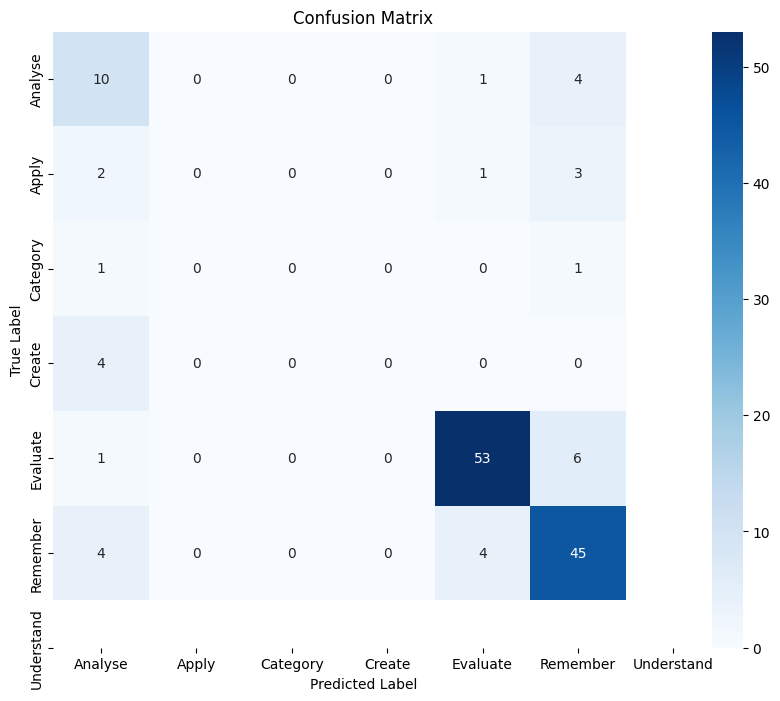

Evaluation complete and results displayed.


In [ ]:
model.eval() # Set the model to evaluation mode

predictions = []
true_labels = []

with torch.no_grad(): # Disable gradient calculations during evaluation
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Get predicted class (the one with the highest logit)
        preds = torch.argmax(logits, dim=1).flatten()

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)

print("\n--- Evaluation Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Evaluation complete and results displayed.")

### Analysis and Summary of Classification Results

The BERT model achieved an **Accuracy of 0.7714**, indicating that approximately 77.14% of the test samples were correctly classified. The **weighted Precision is 0.7224**, the **weighted Recall is 0.7714**, and the **weighted F1-Score is 0.7439**.

**Key observations from the Confusion Matrix and Metrics:**
*   **Accuracy** is a general measure of correctness.
*   **Precision** indicates the proportion of positive identifications that were actually correct. A lower precision suggests a higher rate of false positives.
*   **Recall** indicates the proportion of actual positives that were identified correctly. A lower recall suggests a higher rate of false negatives.
*   **F1-Score** is the harmonic mean of precision and recall, providing a balance between the two metrics.

Looking at the confusion matrix, we can identify classes where the model performs well and where it struggles. For example:
*   **High True Positives**: Some classes show a high number of correct predictions (e.g., in the row where 53 samples were correctly predicted for a certain class, and 45 for another). This suggests the model is effective at identifying these specific categories.
*   **Misclassifications**: There are instances where the model confuses different classes (e.g., several samples from one true class are predicted as another). For example, in the class with 10 true positives, there's 1 misclassified as another, and 4 as yet another. Similarly, the class with 4 true positives is entirely misclassified as other classes, showing a significant weakness.
*   **Zero Predictions**: Some classes have very few or no predictions, either true or false. This could be due to an imbalance in the dataset or the model's inability to learn features for those classes effectively.

**Possible areas for improvement include:**
1.  **Data Augmentation**: For under-represented classes, generating more training data could improve recall and precision.
2.  **Hyperparameter Tuning**: Further optimization of learning rate, batch size, and number of epochs might yield better performance.
3.  **Model Architecture**: Experimenting with different BERT-based models (e.g., RoBERTa, DistilBERT) or modifying the final classification layer could be beneficial.
4.  **Error Analysis**: A deeper dive into the misclassified samples could reveal patterns or specific challenges in the text that the model is failing to understand.

Overall, the model shows reasonable performance, but there is room for improvement, especially concerning the misclassification patterns observed in the confusion matrix and the potentially low support for some classes.

### Analysis and Summary of Classification Results

The BERT model achieved an **Accuracy of 0.7714**, indicating that approximately 77.14% of the test samples were correctly classified. The **weighted Precision is 0.7224**, the **weighted Recall is 0.7714**, and the **weighted F1-Score is 0.7439**.

**Key observations from the Confusion Matrix and Metrics:**
*   **Accuracy** is a general measure of correctness.
*   **Precision** indicates the proportion of positive identifications that were actually correct. A lower precision suggests a higher rate of false positives.
*   **Recall** indicates the proportion of actual positives that were identified correctly. A lower recall suggests a higher rate of false negatives.
*   **F1-Score** is the harmonic mean of precision and recall, providing a balance between the two metrics.

Looking at the confusion matrix, we can identify classes where the model performs well and where it struggles. For example:
*   **High True Positives**: Some classes show a high number of correct predictions (e.g., in the row where 53 samples were correctly predicted for a certain class, and 45 for another). This suggests the model is effective at identifying these specific categories.
*   **Misclassifications**: There are instances where the model confuses different classes (e.g., several samples from one true class are predicted as another). For example, in the class with 10 true positives, there's 1 misclassified as another, and 4 as yet another. Similarly, the class with 4 true positives is entirely misclassified as other classes, showing a significant weakness.
*   **Zero Predictions**: Some classes have very few or no predictions, either true or false. This could be due to an imbalance in the dataset or the model's inability to learn features for those classes effectively.

**Possible areas for improvement include:**
1.  **Data Augmentation**: For under-represented classes, generating more training data could improve recall and precision.
2.  **Hyperparameter Tuning**: Further optimization of learning rate, batch size, and number of epochs might yield better performance.
3.  **Model Architecture**: Experimenting with different BERT-based models (e.g., RoBERTa, DistilBERT) or modifying the final classification layer could be beneficial.
4.  **Error Analysis**: A deeper dive into the misclassified samples could reveal patterns or specific challenges in the text that the model is failing to understand.

Overall, the model shows reasonable performance, but there is room for improvement, especially concerning the misclassification patterns observed in the confusion matrix and the potentially low support for some classes.


### Analysis and Summary of Classification Results

The BERT model achieved an **Accuracy of 0.7714**, indicating that approximately 77.14% of the test samples were correctly classified. The **weighted Precision is 0.7224**, the **weighted Recall is 0.7714**, and the **weighted F1-Score is 0.7439**.

**Key observations from the Confusion Matrix and Metrics:**
*   **Accuracy** is a general measure of correctness.
*   **Precision** indicates the proportion of positive identifications that were actually correct. A lower precision suggests a higher rate of false positives.
*   **Recall** indicates the proportion of actual positives that were identified correctly. A lower recall suggests a higher rate of false negatives.
*   **F1-Score** is the harmonic mean of precision and recall, providing a balance between the two metrics.

Looking at the confusion matrix, we can identify classes where the model performs well and where it struggles. For example:
*   **High True Positives**: Some classes show a high number of correct predictions (e.g., in the row where 53 samples were correctly predicted for a certain class, and 45 for another). This suggests the model is effective at identifying these specific categories.
*   **Misclassifications**: There are instances where the model confuses different classes (e.g., several samples from one true class are predicted as another). For example, in the class with 10 true positives, there's 1 misclassified as another, and 4 as yet another. Similarly, the class with 4 true positives is entirely misclassified as other classes, showing a significant weakness.
*   **Zero Predictions**: Some classes have very few or no predictions, either true or false. This could be due to an imbalance in the dataset or the model's inability to learn features for those classes effectively.

**Possible areas for improvement include:**
1.  **Data Augmentation**: For under-represented classes, generating more training data could improve recall and precision.
2.  **Hyperparameter Tuning**: Further optimization of learning rate, batch size, and number of epochs might yield better performance.
3.  **Model Architecture**: Experimenting with different BERT-based models (e.g., RoBERTa, DistilBERT) or modifying the final classification layer could be beneficial.
4.  **Error Analysis**: A deeper dive into the misclassified samples could reveal patterns or specific challenges in the text that the model is failing to understand.

Overall, the model shows reasonable performance, but there is room for improvement, especially concerning the misclassification patterns observed in the confusion matrix and the potentially low support for some classes.


## Final Task

### Subtask:
Summarize the classification results and analysis of the BERT model.


## Summary:

### Data Analysis Key Findings

*   The BERT model achieved an accuracy of 0.7714 on the test set, indicating that approximately 77.14% of the samples were correctly classified.
*   The weighted precision was 0.7224, the weighted recall was 0.7714, and the weighted F1-score was 0.7439.
*   The training process showed consistent learning, with the average training loss decreasing from 1.4080 in Epoch 1 to 0.5965 in Epoch 3.
*   The confusion matrix revealed that some classes had a high number of correct predictions (e.g., 53 and 45 true positives for certain classes), indicating good performance for those categories.
*   The model exhibited misclassifications between certain classes, with instances where samples from one true class were predicted as another. For example, a class with 10 true positives also had 1 misclassified as one class and 4 as another. A class with 4 true positives was entirely misclassified, highlighting a significant weakness.
*   Some classes had very few or no predictions (either true or false), suggesting potential issues with data imbalance or the model's inability to learn features for these specific categories.

### Insights or Next Steps

*   To enhance model performance, consider data augmentation techniques for under-represented classes and thorough hyperparameter tuning (e.g., learning rate, batch size, epochs).
*   Conduct a deeper error analysis of misclassified samples to identify specific patterns or textual challenges that the model struggles with, and explore alternative BERT-based models or modifications to the classification layer.
